# Imports

In [1]:
#pip install mplsoccer

In [41]:
# importamos todas las librerías necesarias para que aparezca correctament el gráfico
import numpy as np
import pandas as pd
from operator import pos
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, select
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker

import glob
import os

pd.set_option('display.max_rows',30)
pd.set_option('display.max_columns',None)

# **BBDD - Conexión y Lectura**

In [3]:
# Configuración de la conexión a PostgreSQL
usuario = "avnadmin"
contrasena = "AVNS_Snql1CSp1zYrJCH6cXE"
servidor = "my-database-pg-my-data22.f.aivencloud.com"
puerto = "13676"
base_datos = "my_wyscout"

# Crea la cadena de conexión
conexion_str = f'postgresql+psycopg2://{usuario}:{contrasena}@{servidor}:{puerto}/{base_datos}'
engine = create_engine(conexion_str)

In [4]:
s_sql = text("""SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En préstamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios/90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos/90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from jugadores j
union
SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En préstamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios/90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos/90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from hist_jugadores hj
;""")

In [5]:
# Ejecutar la consulta SQL
df = pd.read_sql(s_sql, conexion_str)  # Cargar resultados en un DataFrame

# Tratamiento de los datos

In [54]:
df_players = df.copy()
df_players = df_players.drop_duplicates()
# Renombrar las columnas
df_players.rename(columns={'Minutos jugados': 'Minutos',
                        'Posición específica': "Posición"},
                  inplace=True)

In [7]:
print(df_players.columns.tolist())

['Competición', 'Temporada', 'Posición Principal', 'Jugador', 'Equipo', 'Equipo durante el período seleccionado', 'Posición', 'Edad', 'Valor de mercado', 'Vencimiento contrato', 'Partidos jugados', 'Minutos', 'Goles', 'xG', 'Asistencias', 'xA', 'Duelos/90', 'Duelos ganados %', 'País de nacimiento', 'Pasaporte', 'Pie', 'Altura', 'Peso', 'En préstamo', 'Acciones defensivas realizadas/90', 'Duelos defensivos/90', 'Duelos defensivos ganados %', 'Duelos aéreos/90', 'Duelos aéreos ganados %', 'Entradas/90', 'Acciones de ataque exitosas/90', 'Asistencias/90', 'Asistencias/90.1', 'Ataque en profundidad/90', 'Carreras en progresión/90', 'Centros desde el último tercio/90', 'Centros desde la banda derecha/90', 'Centros/90', 'Desmarques/90', 'Duelos aéreos/90.1', 'Duelos atacantes ganados %', 'Duelos atacantes/90', 'Faltas recibidas/90', 'Faltas/90', 'Goles (excepto los penaltis)', 'Goles de cabeza/90', 'Goles evitados', 'Goles hechos %', 'Goles recibidos/90', 'Goles/90', 'Interceptaciones/90', '

In [8]:
df_players.head(2)

,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios/90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos/90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
0,1DIVI,2018-2018,Central,A. Acevedo,None,O'Higgins,"RCB, CB",41,0,None,22,1803,2,0.93,1,0.91,17.92,56.27,Chile,Chile,derecho,176,74,no,11.73,6.99,67.14,6.19,49.19,0.65,0.65,0.05,0.4,0.3,1.15,0.05,0.55,0.60,0.60,NaN,57.14,1.75,1.05,1.30,2,0.05,NaN,22.222,NaN,0.10,6.39,0.05,21.65,34.18,CHI,0.0,1.10,31.00,7.74,20.97,1.35,31.82,0.6,9.38,13.98,12.38,26.71,40.88,0,0.0,0,9.6,25.0,27.27,0.0,82.30,89.86,74.19,9.09,75.48,86.54,91.79,73.39,55.56,0.45,0,NaN,9,0.45,NaN,0.05,4,0,0.0,0.0,22.22,1.10,0.0,0.0,0.0,0.70,0.05,0.0,0.0,0.05,0.10,0.98,0.30,0.05,0.0,0.0,2025-09-17 11:29:45.576589,1,NaN,0,0.55,2.60,25.0,60.11,0.20
1,1DIVI,2018-2018,Central,A. Contreras,Nueva Chicago,Universidad de Chile,RCB,31,100000,2024-12-31,10,769,1,0.24,0,0.00,15.92,55.88,Chile,Chile,derecho,185,80,no,11.82,7.49,67.19,4.21,50.00,1.29,0.70,0.00,0.0,0.0,0.70,0.00,0.23,0.23,0.12,NaN,41.67,1.40,0.82,1.29,1,0.00,NaN,33.333,NaN,0.12,5.50,0.00,18.53,28.71,CHI,0.0,0.23,29.96,3.75,13.93,1.87,0.00,0.7,3.86,14.04,6.32,21.65,34.06,0,0.0,0,8.7,0.0,0.00,0.0,84.19,89.84,65.63,100.00,77.31,89.29,92.50,59.26,100.00,0.47,0,NaN,3,0.35,NaN,0.00,2,0,0.0,0.0,33.33,0.35,0.0,0.0,0.0,0.59,0.00,0.0,0.0,0.03,0.12,2.04,0.47,0.00,0.0,0.0,2025-09-17 11:29:45.576589,0,NaN,0,0.12,3.28,100.0,45.45,0.23


# Métricas

In [9]:
fase_defensiva = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
                'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos defensivos/90','Entradas/90',
                'Faltas/90','Interceptaciones/90','Posesión conquistada después de una entrada',
                'Posesión conquistada después de una interceptación','Tarjetas amarillas','Tarjetas amarillas/90',
                'Tarjetas rojas','Tarjetas rojas/90','Tiros interceptados/90']

abp = ['Córneres/90','Penaltis a favor','Penaltis realizados %','Tiros libres directos %',
       'Tiros libres directos/90','Tiros libres/90']

acc_ofensivas = ['Acciones de ataque exitosas/90','Aceleraciones/90','Asistencias','Asistencias/90',
                'Carreras en progresión/90','Centros al área pequeña/90','Centros desde la banda derecha/90',
                'Centros desde la banda izquierda/90','Centros/90','Duelos atacantes ganados %',
                'Duelos atacantes/90','Faltas recibidas/90','Goles','Goles (excepto los penaltis)',
                'Goles de cabeza','Goles de cabeza/90','Goles hechos %','Goles, excepto los penaltis/90',
                'Goles/90','Pases largos recibidos/90','Pases recibidos /90','Precisión centros %',
                'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
                'Regates realizados %','Regates/90','Remates','Remates/90','Tiros a la portería %',
                'Toques en el área de penalti/90','xG','xG/90']

fisica = ['Total Distance per 90','Running Distance per 90 (15-20 km/h)','HSR Distance per 90 (20-25 km/h)',
          'Sprinting Distance per 90 (+25 km/h)','HI Distance per 90 (+20 km/h)','Meter/Min','Max Speed (km/h)',
          'Count Medium Acceleration per 90 (1.5 m/s² to 3 m/s²)','Count High Acceleration per 90 (+3 m/s²)',
          'Count Medium Deceleration per 90 (-1.5 m/s² to -3 m/s²)','Count High Deceleration per 90 (-3 m/s²)',
          'Count HSR per 90 (20-25 km/h)','Count Sprint per 90 (+25 km/h)','Count HI per 90 (+20 km/h)']

jugadas_clave = ['Asistencias','Asistencias/90',
                'Ataque en profundidad/90','Centros desde el último tercio/90','Desmarques/90',
                'Jugadas claves/90','Pases al área de penalti/90','Pases en el último tercio/90',
                'Pases en profundidad/90','Pases hacía el área pequeña %','Pases progresivos/90',
                'Precisión desmarques %','Precisión pases en el último tercio %',
                'Precisión pases en profundidad %','Precisión pases progresivos %','Second assists/90',
                'Third assists/90','xA','xA/90']

organizacion = ['Longitud media pases largos, m','Longitud media pases, m','Pases cortos / medios /90',
                'Pases hacia adelante/90','Pases hacia atrás/90','Pases largos/90','Pases laterales/90',
                'Pases/90','Precisión pases %','Precisión pases cortos / medios %',
                'Precisión pases hacia adelante %','Precision pases hacia atrás %','Precisión pases largos %',
                'Precisión pases laterales %']

portero = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
          'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos ganados %','Goles evitados',
          'Goles evitados/90','Goles recibidos','Goles recibidos/90','Longitud media pases largos, m',
          'Longitud media pases, m','Paradas %','Pases hacia adelante/90',
          'Pases hacía atrás recibidos del arquero/90','Pases hacia atrás/90','Pases largos/90',
          'Pases laterales/90','Pases/90','Porterías imbatidas en los 90','Precisión pases %',
          'Precisión pases cortos / medios %','Precisión pases hacia adelante %',
          'Precision pases hacia atrás %','Precisión pases largos %','Precisión pases laterales %',
          'Remates en contra','Remates en contra/90','Salidas/90','xG en contra','xG en contra/90']

Finalización = ['Goles', 'Goles (excepto los penaltis)', 'Goles de cabeza', 'Goles de cabeza/90',
                'Goles hechos %', 'Goles, excepto los penaltis/90', 'Goles/90', 'Remates', 'Remates/90',
                'Tiros a la portería %', 'xG/90'
                ]

Delantero = ['Goles', 'Goles/90', 'Duelos atacantes ganados %', 'Duelos aéreos ganados %',
             'Remates/90', 'Regates/90', 'Toques en el área de penalti/90', 'Tiros a la portería %',
             'xG/90', 'xA/90', 'Regates realizados %'
            ]

Extremo = ['Regates realizados %', 'Centros desde la banda izquierda/90', 'Centros desde la banda derecha/90',
           'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
           'Duelos atacantes ganados %', 'Goles', 'xG/90', 'Aceleraciones/90'
          ]

# **ANÁLISIS**

📊 **Ponderación general sugerida (según perfil de delantero)**


xG/90         G/90-xG/90 (Eficiencia)       xA/90 o Asistencias/90      Desmarques/90 o Carreras en progresión/90


Finalizador puro (9 de área)	50%	30%	10%	10%


Delantero móvil / moderno (tipo Haaland, Osimhen)	40%	25%	20%	15%


Delantero asociativo / falso 9	30%	15%	30%	25%

In [55]:
#Si es delantero añadimos dos columnas nuevas EFICIENCIA
df_players["Eficiencia"] = df_players["Goles"] - df_players["xG"]
df_players["Eficiencia/90"] = df_players["Goles/90"] - df_players["xG/90"]

In [11]:
#SELECCIONAR METRICAS SEGÚN PERFIL A BUSCAR
stats_cols = ["xG/90",
            "Eficiencia/90",
            "xA/90",
            "Desmarques/90"
            ]

#Podríamos añadir:
    # Desmarques/90 o Carreras en progresión/90
    # Toques en el área de penalti/90 --> presencia en zona de remate
    # Tiros a la portería% --> precisión de disparo
    # Acciones de ataque exitosas/90 --> fiabilidad ofensiva general

In [56]:
# Concatenar las dos columnas
df_players['Jugador-Eq'] = df_players['Jugador'] + ' (' + df_players['Equipo durante el período seleccionado'] + ')'

In [57]:
#Nos quedamos con las metricas que nos interesan
df_data = df_players[["Temporada", "Competición", "Jugador-Eq", "Edad", "Minutos","Posición"] + stats_cols].dropna().reset_index(drop=True)
df_data.head(5)

,Temporada,Competición,Jugador-Eq,Edad,Minutos,Posición,xG/90,Eficiencia/90,xA/90,Desmarques/90
0,2018-2018,1DIVI,A. Acevedo (O'Higgins),41,1803,"RCB, CB",0.05,0.05,0.05,0.60
1,2018-2018,1DIVI,A. Contreras (Universidad de Chile),31,769,RCB,0.03,0.09,0.00,0.12
2,2018-2018,1DIVI,A. Díaz (Palestino),29,58,RCB,0.00,0.00,0.00,0.00
3,2018-2018,1DIVI,A. González (Palestino),36,960,RCB,0.00,0.00,0.00,0.00
4,2018-2018,1DIVI,Á. Pizzorno (Unión Española),32,1443,LCB,0.03,-0.03,0.00,0.06


In [14]:
#ver tipo de datos por si alguno tipo numerico no lo fuera
df_data.dtypes

,0
Temporada,object
Competición,object
Jugador-Eq,object
Edad,int64
Minutos,int64
Posición,object
xG/90,float64
Eficiencia/90,float64
xA/90,float64
Desmarques/90,float64


In [58]:
# ------------------------------------------------------------
# Normalización → percentiles internos (0–100)
# ------------------------------------------------------------
metrics_plus = stats_cols

def to_percentiles(s):
    order = s.rank(method="average")
    return 100*(order-1)/(len(s)-1)

for m in metrics_plus:
    df_data[m + "_pct"]  = to_percentiles(df_data[m])

In [59]:
df_data.head(2)

,Temporada,Competición,Jugador-Eq,Edad,Minutos,Posición,xG/90,Eficiencia/90,xA/90,Desmarques/90,xG/90_pct,Eficiencia/90_pct,xA/90_pct,Desmarques/90_pct
0,2018-2018,1DIVI,A. Acevedo (O'Higgins),41,1803,"RCB, CB",0.05,0.05,0.05,0.60,46.810287,86.429245,57.566985,85.010098
1,2018-2018,1DIVI,A. Contreras (Universidad de Chile),31,769,RCB,0.03,0.09,0.00,0.12,34.995287,91.851353,13.667699,48.614515


In [60]:
#FILTROS
min = 1500
edad = 25
pos = 'CF'
comp = '1DIVI'
temp = '2024-2025'

if comp == '1RFEF':
  comp2 = '1ª RFEF'
elif comp == '2RFEF':
  comp2 = '2ª RFEF'
elif comp == '1DIVI':
  comp2 = '1ª DIVI'
elif comp == '2DIVI':
  comp2 = '2ª DIVI'

In [61]:
# -------------------------------
# FILTRAR JUGADORES RELEVANTES
# -------------------------------
df_filt = df_data[(df_data['Minutos'] > min) &
                  (df_data['Edad'] <= edad) &
                  (df_data['Posición'].str.contains(pos)) &
                  (df_data['Competición'].isin([comp])) &
                  (df_data['Temporada'].isin([temp]))
                ].reset_index(drop=True)
df_filt.head(5)

,Temporada,Competición,Jugador-Eq,Edad,Minutos,Posición,xG/90,Eficiencia/90,xA/90,Desmarques/90,xG/90_pct,Eficiencia/90_pct,xA/90_pct,Desmarques/90_pct
0,2024-2025,1DIVI,André Almeida (Valencia),25,2165,"AMF, CF, LW",0.04,-0.04,0.18,0.37,41.187559,27.237108,93.803689,73.343207
1,2024-2025,1DIVI,Oihan Sancet (Athletic Bilbao),25,1758,"AMF, CF",0.43,0.34,0.03,0.36,96.686414,99.011714,46.325569,72.655177
2,2024-2025,1DIVI,C. Uche (Getafe),22,2692,"CF, LW",0.14,-0.01,0.07,0.07,73.372829,43.920829,67.397334,41.658812
3,2024-2025,1DIVI,Fábio Silva (Las Palmas),22,2020,CF,0.40,0.05,0.08,0.09,95.753332,85.501548,71.714016,44.441901
4,2024-2025,1DIVI,Hugo Duro (Valencia),25,2377,CF,0.32,0.10,0.03,0.08,92.266056,92.489565,46.325569,43.063148


In [47]:
#Delantero centro PURO
weights_DF_puro = {
                  "xG/90_pct":                    0.50,
                  "Eficiencia/90_pct":            0.30,
                  "xA/90_pct":                    0.10,
                  "Desmarques/90_pct":            0.10
                  }

#Delantero centro ASOCIATIVO O FALSO 9
weights_DF_asociativo = {
                        "xG/90_pct":                    0.30,
                        "Eficiencia/90_pct":            0.20,
                        "xA/90_pct":                    0.30,
                        "Desmarques/90_pct":            0.20
                        }

#Delantero centro RUPTURA
weights_DF_ruptura = {
                      "xG/90_pct":                    0.35,
                      "Eficiencia/90_pct":            0.20,
                      "xA/90_pct":                    0.15,
                      "Desmarques/90_pct":            0.30
                      }

In [71]:
def fit_score(row, weights):
    return sum(row[k]*w for k,w in weights.items())

#df_filt["FitScore"]  = df_filt.apply(lambda r: fit_score(r, weights_DF_puro), axis=1)
#df_filt["FitScore"]  = df_filt.apply(lambda r: fit_score(r, weights_DF_asociativo), axis=1)
df_filt["FitScore"]  = df_filt.apply(lambda r: fit_score(r, weights_DF_ruptura), axis=1)

tipo_perfil_buscado = "Delantero Ruptura"

In [72]:
df_filt.sort_values("FitScore", ascending=False).head(5)

,Temporada,Competición,Jugador-Eq,Edad,Minutos,Posición,xG/90,Eficiencia/90,xA/90,Desmarques/90,xG/90_pct,Eficiencia/90_pct,xA/90_pct,Desmarques/90_pct,FitScore
6,2024-2025,1DIVI,J. Álvarez (Atlético Madrid),25,2716,"CF, LW",0.41,0.15,0.23,0.43,96.087249,96.216507,97.150936,77.121314,90.582873
1,2024-2025,1DIVI,Oihan Sancet (Athletic Bilbao),25,1758,"AMF, CF",0.43,0.34,0.03,0.36,96.686414,99.011714,46.325569,72.655177,82.387976
13,2024-2025,1DIVI,Álex Baena (Villarreal),23,2837,"LW, CF",0.22,0.00,0.38,0.48,84.194156,63.156052,99.597415,79.823617,80.985862
12,2024-2025,1DIVI,Vinícius Júnior (Real Madrid),24,2415,"CF, LAMF, LWF",0.49,-0.08,0.28,0.89,97.911674,13.020062,98.584893,92.655177,79.457385
14,2024-2025,1DIVI,Rodrygo (Real Madrid),24,2077,"RAMF, CF, RWF",0.21,0.05,0.14,0.22,83.154706,86.916655,88.404470,60.523765,77.905278


In [73]:
#Ordenar dataset
rank = df_filt.sort_values("FitScore", ascending=False).reset_index(drop=True)

#rank.to_csv('Rank_Fichajes_MC.csv', index=False)

def quick_reason(row):
    reasons = []
    if row["xG/90_pct"] > 70: reasons.append("goleador")
    if row["Eficiencia/90_pct"] > 70: reasons.append("eficiencia goleadora")
    if row["xA/90_pct"] > 70: reasons.append("asistencias")
    if row["Desmarques/90_pct"] > 70: reasons.append("desmarques")
    return ", ".join(reasons) if reasons else "perfil equilibrado"

top5 = rank[["Jugador-Eq","Edad","FitScore"]].head(5).copy()
print("\nTOP-5")
print(top5.head().to_string(index=False))

print("\nRecomendación rápida:")
for i in range(1):
    r = rank.loc[i]
    print(r)
    print(f"- {i+1}) {r['Jugador-Eq']} → razones: {quick_reason(r)}.")


TOP-5
                    Jugador-Eq  Edad  FitScore
  J. Álvarez (Atlético Madrid)    25 90.582873
Oihan Sancet (Athletic Bilbao)    25 82.387976
       Álex Baena (Villarreal)    23 80.985862
 Vinícius Júnior (Real Madrid)    24 79.457385
         Rodrygo (Real Madrid)    24 77.905278

Recomendación rápida:
Temporada                               2024-2025
Competición                                 1DIVI
Jugador-Eq           J. Álvarez (Atlético Madrid)
Edad                                           25
Minutos                                      2716
Posición                                   CF, LW
xG/90                                        0.41
Eficiencia/90                                0.15
xA/90                                        0.23
Desmarques/90                                0.43
xG/90_pct                               96.087249
Eficiencia/90_pct                       96.216507
xA/90_pct                               97.150936
Desmarques/90_pct                     

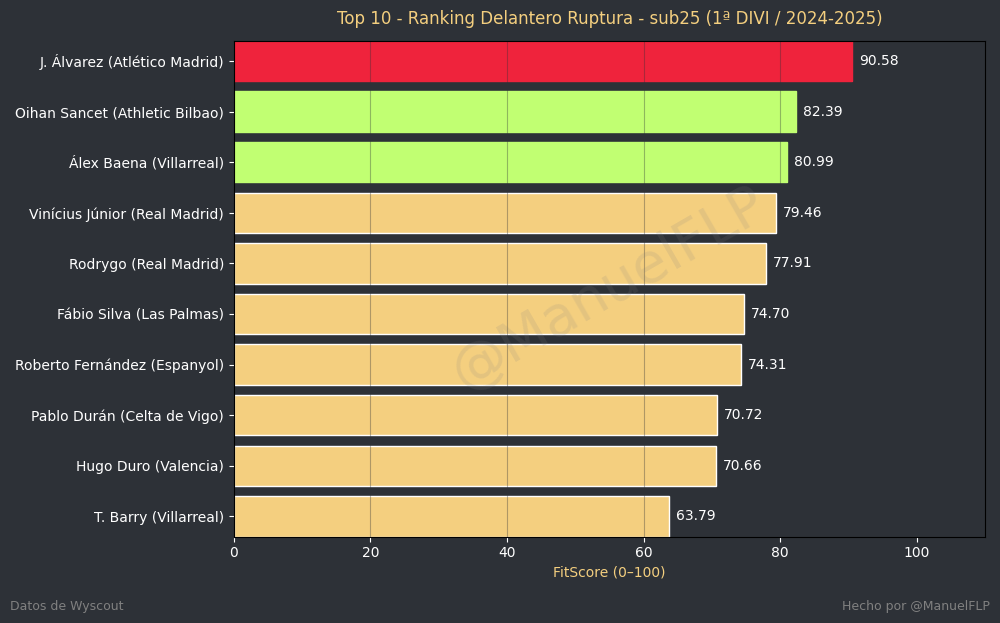

In [74]:
# ---------- Estilo ----------
BG    = "#2d3137"
WHITE = "#ffffff"
GRID  = "#2d3137"
TIT = "#f4cf7f"  # amarillo crema
ACCENT = "#DC143C"  # Rojo carmesí
KEY = "#c1ff72"  # verde lima
IMPACT = "#ef233c"  # rojo

# Visualización
plt.rcParams['axes.facecolor'] = BG
plt.rcParams['text.color'] = WHITE
plt.rcParams['axes.labelcolor'] = WHITE
plt.rcParams['xtick.color'] = WHITE
plt.rcParams['ytick.color'] = WHITE

#Ranking Graf. Barras
fig1, ax1 = plt.subplots(figsize=(10, 6), facecolor=BG)
#fig1.patch.set_facecolor(BG)
ax1.barh(
    rank["Jugador-Eq"].head(10)[::-1],
    rank["FitScore"].head(10)[::-1],
    color=ACCENT, edgecolor=WHITE, linewidth=0.6, alpha=0.95
)

# Barras horizontales
bars = ax1.barh(rank["Jugador-Eq"].head(10), rank["FitScore"].head(10), color=TIT, edgecolor="white")

# Etiquetas de valor al final de cada barra
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 1, bar.get_y() + bar.get_height()/2,
            f"{width:.2f}", va='center', ha='left',
            color="white", fontsize=10)

#CAMBIAR TITULO SEGÚN ANÁLISIS *****************************************************************************
ax1.set_title("Top 10 - Ranking " + tipo_perfil_buscado + " - sub25 (" + comp2 + " / " + temp +")", pad=12, color=TIT)

ax1.set_xlabel("FitScore (0–100)", color=TIT)
ax1.grid(True, axis="x", alpha=0.35, color=GRID)

# Límites extendidos hasta 110
ax1.set_xlim(0, 110)

# Créditos y marca de agua
plt.figtext(0.01, -0.025, "Datos de Wyscout", ha="left", fontsize=9, color="gray")
plt.figtext(0.99, -0.025, "Hecho por @ManuelFLP", ha="right", fontsize=9, color="gray")
plt.text(0.5, 0.5, "@ManuelFLP",
         transform=plt.gca().transAxes, fontsize=40, color="gray",
         alpha=0.15, ha="center", va="center", rotation=30)

# Resalta #1 en rojo, #2-#3 en verde lima
for i, b in enumerate(bars):
    if i == 0:
        b.set_color(IMPACT)
    elif i < 3:
        b.set_color(KEY)

ax1.margins(x=0, y=0)
plt.tight_layout()
#plt.savefig("Scouting.png", dpi=240)
plt.show()

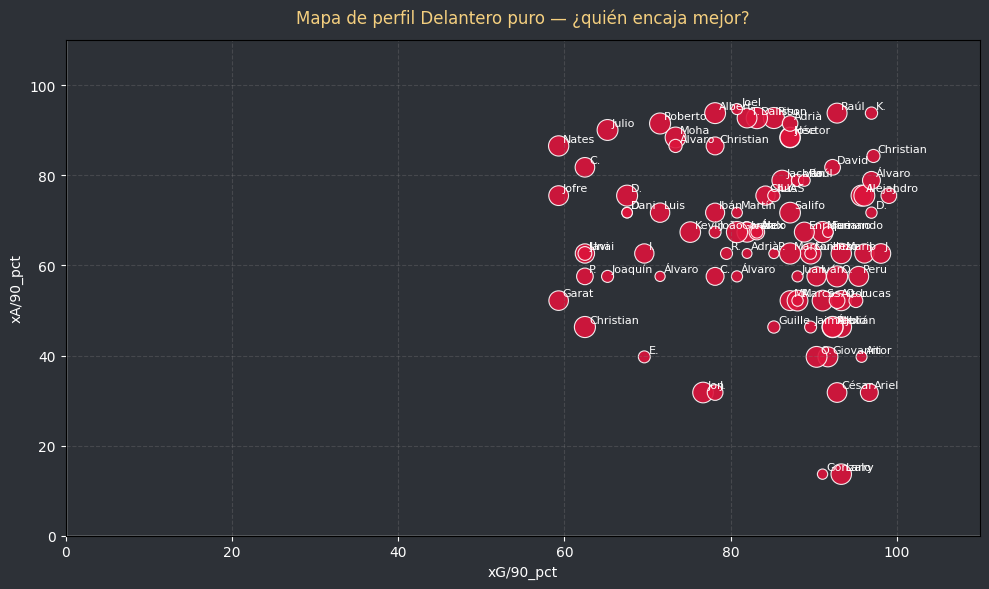

In [24]:
# Graf. Scatter
fig2, ax2 = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor(BG)

x = rank["xG/90_pct"]
y = rank["xA/90_pct"]
s = 200 * (rank["Eficiencia/90_pct"]/100 + 0.2)

ax2.scatter(x, y, s=s, c=ACCENT, edgecolors=WHITE, linewidths=0.8, alpha=0.9)
for _, r in rank.iterrows():
    ax2.annotate(r["Jugador-Eq"].split()[0],
                 (r["xG/90_pct"], r["xA/90_pct"]),
                 xytext=(3,3), textcoords="offset points",
                 fontsize=8, color=WHITE)

# Ajustar cuadrícula
ax2.grid(True, color='gray', linestyle='--', alpha=0.3)
# Asegurar que los ejes no tengan margen adicional
ax2.margins(x=0, y=0)

# Ejes en 0
ax2.axhline(y=0, color="white", linewidth=1)
ax2.axvline(x=0, color="white", linewidth=1)
# Límites extendidos hasta 110
ax2.set_xlim(0, 110)
ax2.set_ylim(0, 110)

ax2.set_xlabel("xG/90_pct")
ax2.set_ylabel("xA/90_pct")
ax2.set_title("Mapa de perfil Delantero puro — ¿quién encaja mejor?", pad=12, color=TIT)
#ax2.grid(True, alpha=0.35, color='white')
plt.tight_layout()

plt.show()